focuses on where orders and revenue are concentrated geographically.

Goals:

Map order density and revenue per state/city/zip code.

Identify high-demand regions and potential logistics bottlenecks.

Highlight revenue vs delivery efficiency by region.

Provide insights for strategic warehouse placement, marketing targeting, and logistics planning.

Geography requires separate lookup logic and map-oriented visualizations, which are best handled independently.

In [ ]:

pip install geopandas



SyntaxError: invalid syntax (1246119378.py, line 2)

   geolocation_state  order_count  total_revenue  avg_delivery_time  late_rate
25                SP        41731     5996050.41           8.297349   0.051688
18                RJ        12839     2142349.25          14.846840   0.124153
10                MG        11624     1871072.52          11.534990   0.050929
22                RS         5462      890584.82          14.817603   0.064262
17                PR         5034      810280.15          11.505090   0.044497
23                SC         3637      623086.43          14.479560   0.089359
4                 BA         3371      615203.62          18.844212   0.126372
8                 GO         2011      349377.13          15.150924   0.072601
6                 DF         1969      326095.81          12.486698   0.065515
7                 ES         2027      325490.67          15.295123   0.114948


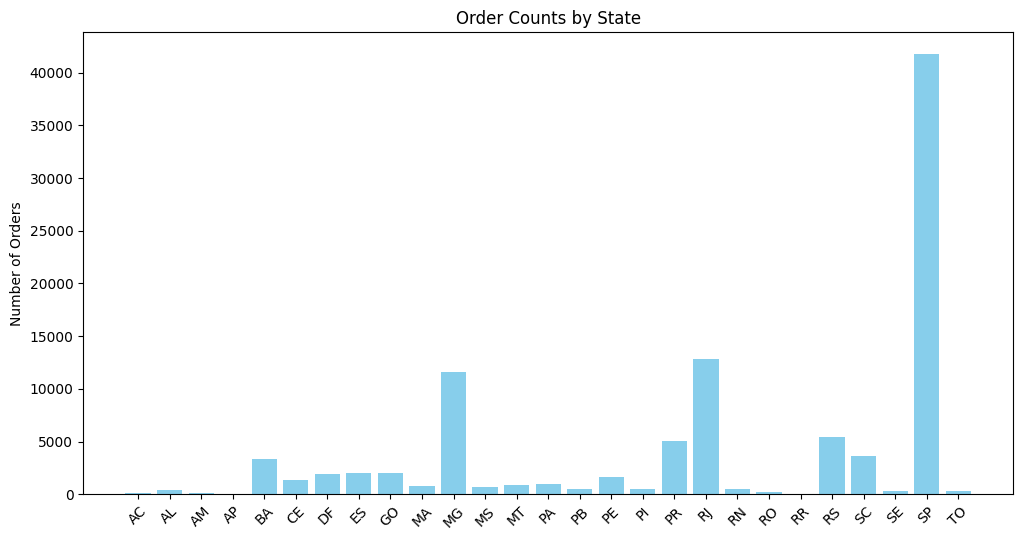

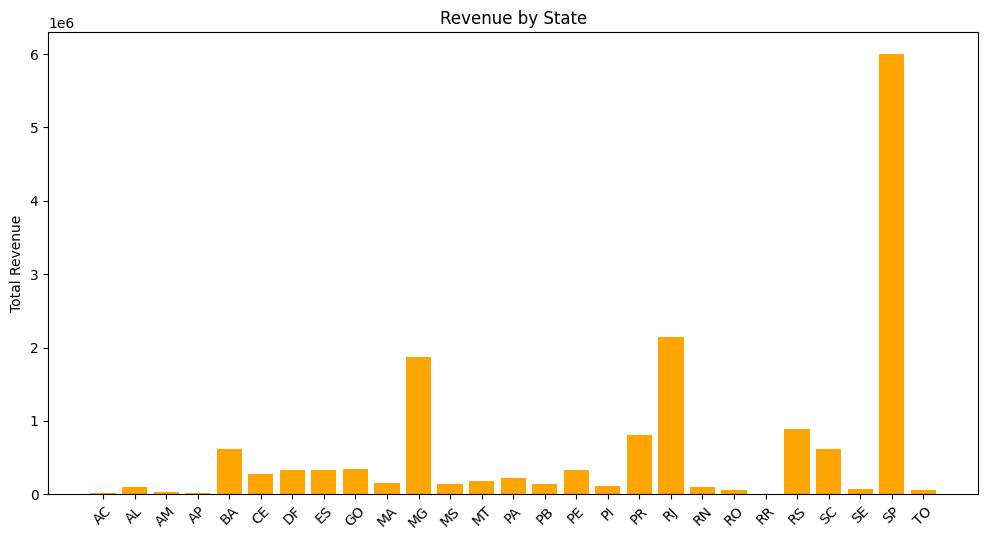

AttributeError: module 'geodatasets' has no attribute 'load_dataset'

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import geodatasets as gd  # new package

# --- Load order-level dataset ---
orders = pd.read_csv(
    r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_order_level.csv",
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
)

# --- Load geolocation lookup ---
geo_lookup = pd.read_csv(
    r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_geolocation_lookup.csv"
)

# --- Merge orders with geolocation using correct column ---
orders_geo = orders.merge(
    geo_lookup,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

# --- Aggregate metrics per state ---
state_stats = orders_geo.groupby("geolocation_state").agg(
    order_count=("order_id", "nunique"),
    total_revenue=("total_payment_value", "sum"),
    avg_delivery_time=("delivery_time_days", "mean"),
    late_rate=("delivery_delay_days", lambda x: (x>0).mean())
).reset_index()

# Top 10 states by revenue
print(state_stats.sort_values("total_revenue", ascending=False).head(10))

# --- Bar chart: Orders per state ---
plt.figure(figsize=(12,6))
plt.bar(state_stats["geolocation_state"], state_stats["order_count"], color="skyblue")
plt.xticks(rotation=45)
plt.ylabel("Number of Orders")
plt.title("Order Counts by State")
plt.show()

# --- Bar chart: Revenue per state ---
plt.figure(figsize=(12,6))
plt.bar(state_stats["geolocation_state"], state_stats["total_revenue"], color="orange")
plt.xticks(rotation=45)
plt.ylabel("Total Revenue")
plt.title("Revenue by State")
plt.show()

# --- Map Visualization (GeoPandas) ---
if {"geolocation_lat", "geolocation_lng"}.issubset(orders_geo.columns):
    geo_gdf = gpd.GeoDataFrame(
        orders_geo,
        geometry=gpd.points_from_xy(orders_geo["geolocation_lng"], orders_geo["geolocation_lat"]),
        crs="EPSG:4326"
    )
    
    # Aggregate by city
    city_stats = geo_gdf.groupby(["geolocation_city", "geolocation_state"]).agg(
        order_count=("order_id", "nunique"),
        total_revenue=("total_payment_value", "sum"),
        avg_delivery_time=("delivery_time_days", "mean")
    ).reset_index()
    
    # Merge with city coordinates
    city_stats = city_stats.merge(
        geo_lookup[["geolocation_city", "geolocation_state", "geolocation_lat", "geolocation_lng"]],
        on=["geolocation_city","geolocation_state"],
        how="left"
    )
    
    city_gdf = gpd.GeoDataFrame(
        city_stats,
        geometry=gpd.points_from_xy(city_stats["geolocation_lng"], city_stats["geolocation_lat"]),
        crs="EPSG:4326"
    )
    
    # --- Load world map via geodatasets ---
    world = gd.load_dataset("naturalearth_lowres", as_gdf=True)
    
    # Plot Brazil map with city bubbles
    fig, ax = plt.subplots(figsize=(12,8))
    world[world.name == "Brazil"].plot(ax=ax, color="lightgrey")
    
    city_gdf.plot(
        ax=ax,
        markersize=city_gdf["total_revenue"]/1000,  # scale bubble size
        alpha=0.6,
        color="orange",
        edgecolor="k"
    )
    
    plt.title("Geographic Distribution of Revenue by City")
    plt.show()
    
    # --- Innovative: Heatmap by State (average delivery time) ---
    state_gdf = orders_geo.groupby("geolocation_state").agg(
        avg_delivery_time=("delivery_time_days", "mean")
    ).reset_index()
    
    state_geo = geo_lookup.drop_duplicates("geolocation_state")[["geolocation_state", "geolocation_lat", "geolocation_lng"]]
    state_gdf = state_gdf.merge(state_geo, on="geolocation_state", how="left")
    
    state_gdf = gpd.GeoDataFrame(
        state_gdf,
        geometry=gpd.points_from_xy(state_gdf["geolocation_lng"], state_gdf["geolocation_lat"]),
        crs="EPSG:4326"
    )
    
    fig, ax = plt.subplots(figsize=(12,8))
    world[world.name == "Brazil"].plot(ax=ax, color="lightgrey")
    state_gdf.plot(
        ax=ax,
        markersize=state_gdf["avg_delivery_time"]*10,  # scale to visualize
        color="red",
        alpha=0.5
    )
    plt.title("State-level Average Delivery Time (Bubble Size)")
    plt.show()


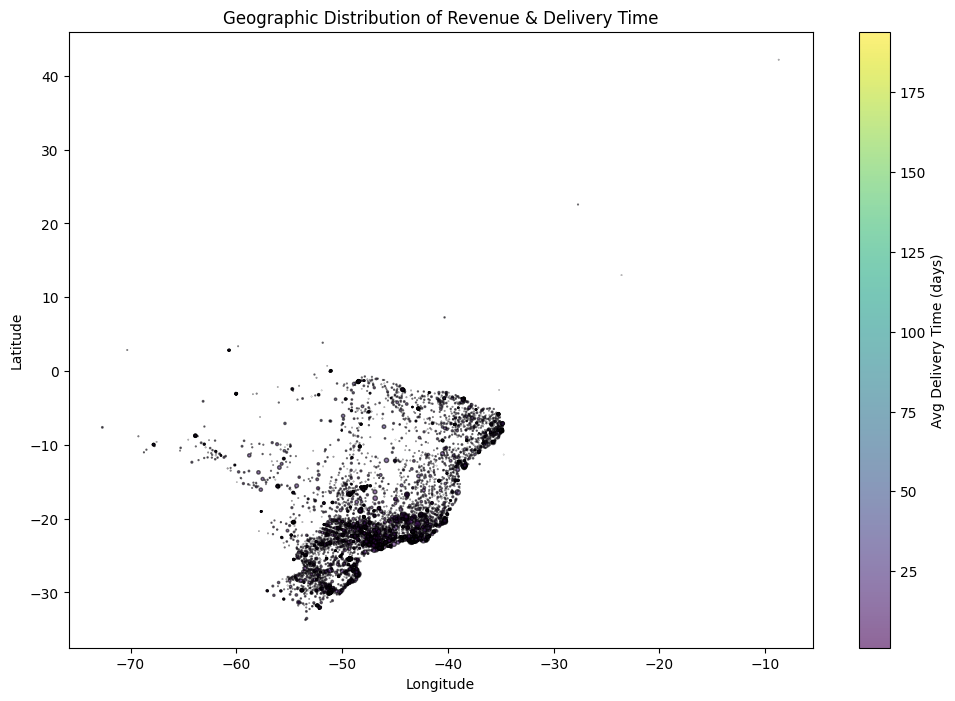

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# Load order-level dataset
orders = pd.read_csv(
    r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_order_level.csv",
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
)

# Load geolocation lookup
geo_lookup = pd.read_csv(
    r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_geolocation_lookup.csv"
)

# Merge orders with geo lookup
orders_geo = orders.merge(
    geo_lookup,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

# Create GeoDataFrame for customer points
geo_gdf = gpd.GeoDataFrame(
    orders_geo,
    geometry=gpd.points_from_xy(orders_geo["geolocation_lng"], orders_geo["geolocation_lat"]),
    crs="EPSG:4326"
)

# Aggregate metrics per city
city_stats = geo_gdf.groupby(
    ["geolocation_city", "geolocation_state", "geolocation_lat", "geolocation_lng"]
).agg(
    order_count=("order_id","nunique"),
    total_revenue=("total_payment_value","sum"),
    avg_delivery_time=("delivery_time_days","mean")
).reset_index()

# Plot lat vs lng scatter with bubble size = revenue
plt.figure(figsize=(12,8))
plt.scatter(
    city_stats["geolocation_lng"],
    city_stats["geolocation_lat"],
    s=city_stats["total_revenue"] / 1000,  # bubble size
    c=city_stats["avg_delivery_time"],     # color by average delivery time
    cmap="viridis",
    alpha=0.6,
    edgecolor="k"
)
plt.colorbar(label="Avg Delivery Time (days)")
plt.title("Geographic Distribution of Revenue & Delivery Time")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


   geolocation_state  order_count  total_revenue  avg_delivery_time  late_rate
25                SP        41731     5996050.41           8.297349   0.051688
18                RJ        12839     2142349.25          14.846840   0.124153
10                MG        11624     1871072.52          11.534990   0.050929
22                RS         5462      890584.82          14.817603   0.064262
17                PR         5034      810280.15          11.505090   0.044497
23                SC         3637      623086.43          14.479560   0.089359
4                 BA         3371      615203.62          18.844212   0.126372
8                 GO         2011      349377.13          15.150924   0.072601
6                 DF         1969      326095.81          12.486698   0.065515
7                 ES         2027      325490.67          15.295123   0.114948


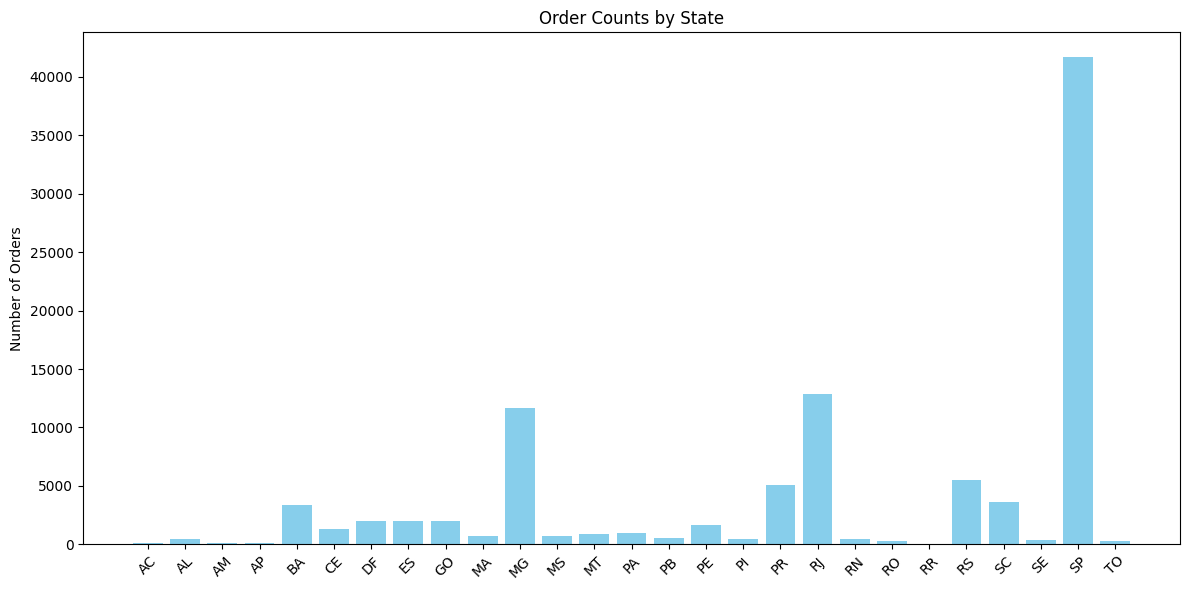

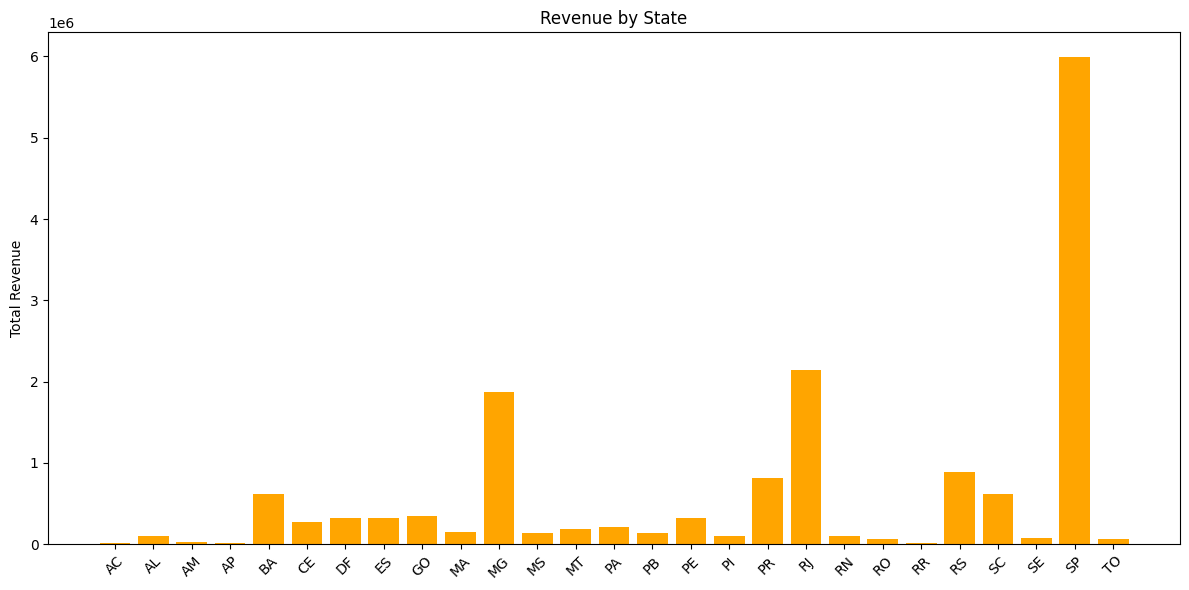

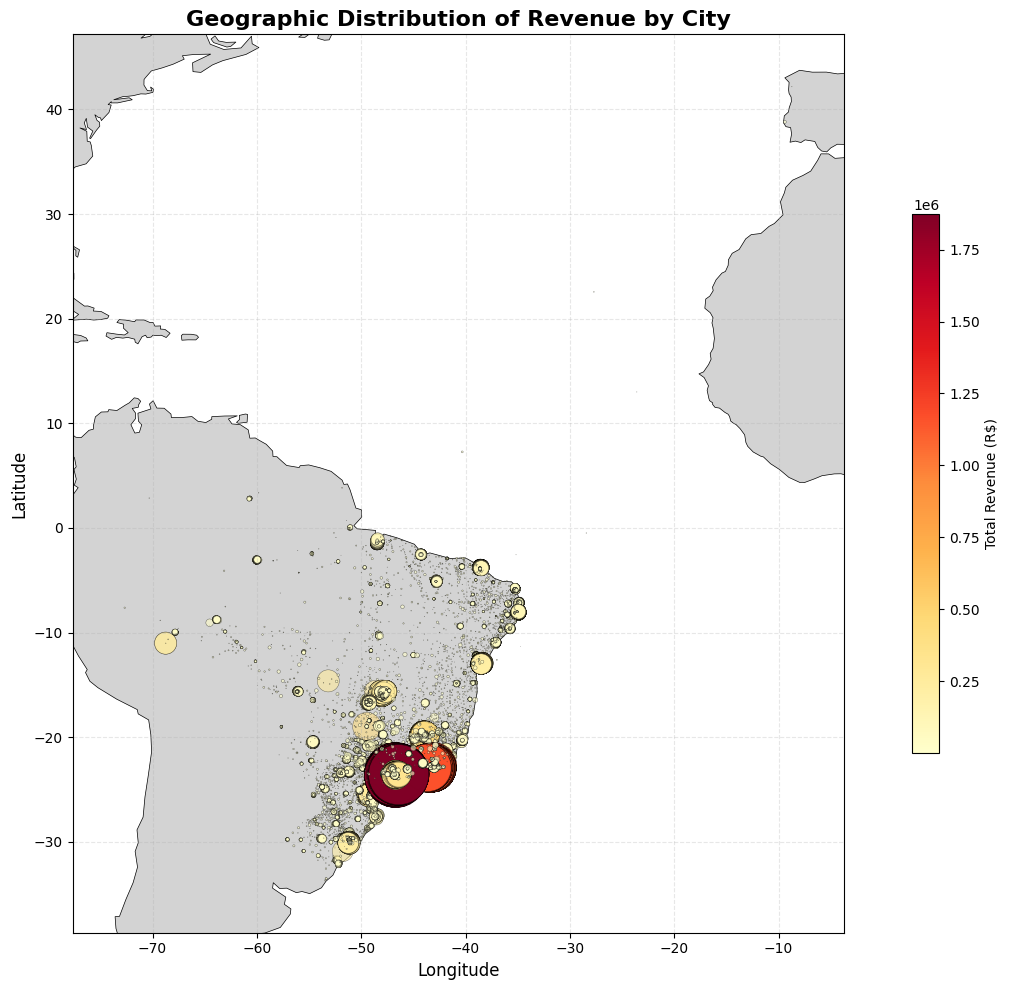

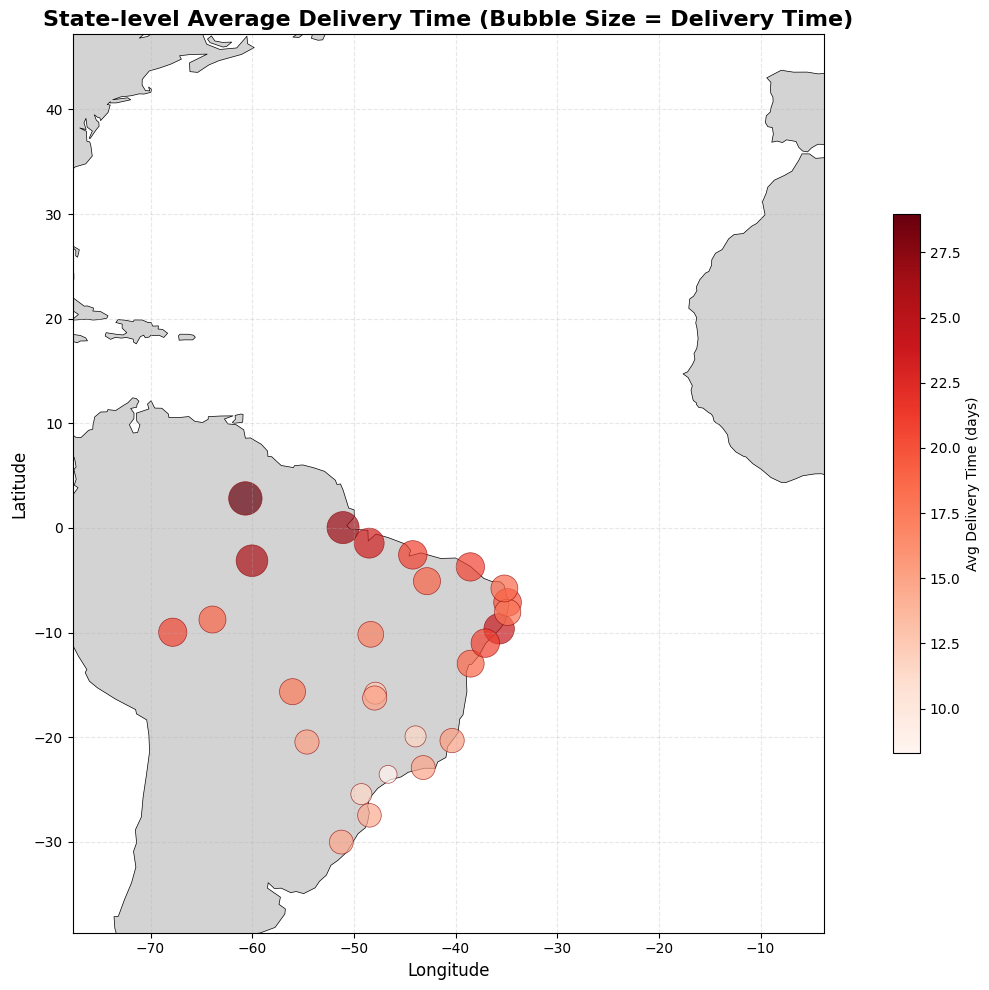


=== TOP 10 CITIES BY REVENUE ===
geolocation_city geolocation_state  total_revenue  order_count  avg_delivery_time
       sao paulo                SP     1873661.56        13207           7.566794
       sao paulo                SP     1873661.56        13207           7.566794
       sao paulo                SP     1873661.56        13207           7.566794
       sao paulo                SP     1873661.56        13207           7.566794
       sao paulo                SP     1873661.56        13207           7.566794
       sao paulo                SP     1873661.56        13207           7.566794
       sao paulo                SP     1873661.56        13207           7.566794
       sao paulo                SP     1873661.56        13207           7.566794
       sao paulo                SP     1873661.56        13207           7.566794
       sao paulo                SP     1873661.56        13207           7.566794

=== STATES WITH LONGEST DELIVERY TIMES ===
geolocation_state  a

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import geodatasets

# --- Load order-level dataset ---
orders = pd.read_csv(
    r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_order_level.csv",
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
)

# --- Load geolocation lookup ---
geo_lookup = pd.read_csv(
    r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_geolocation_lookup.csv"
)

# --- Merge orders with geolocation using correct column ---
orders_geo = orders.merge(
    geo_lookup,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

# --- Aggregate metrics per state ---
state_stats = orders_geo.groupby("geolocation_state").agg(
    order_count=("order_id", "nunique"),
    total_revenue=("total_payment_value", "sum"),
    avg_delivery_time=("delivery_time_days", "mean"),
    late_rate=("delivery_delay_days", lambda x: (x>0).mean())
).reset_index()

# Top 10 states by revenue
print(state_stats.sort_values("total_revenue", ascending=False).head(10))

# --- Bar chart: Orders per state ---
plt.figure(figsize=(12,6))
plt.bar(state_stats["geolocation_state"], state_stats["order_count"], color="skyblue")
plt.xticks(rotation=45)
plt.ylabel("Number of Orders")
plt.title("Order Counts by State")
plt.tight_layout()
plt.show()

# --- Bar chart: Revenue per state ---
plt.figure(figsize=(12,6))
plt.bar(state_stats["geolocation_state"], state_stats["total_revenue"], color="orange")
plt.xticks(rotation=45)
plt.ylabel("Total Revenue")
plt.title("Revenue by State")
plt.tight_layout()
plt.show()

# --- Map Visualization (GeoPandas) ---
if {"geolocation_lat", "geolocation_lng"}.issubset(orders_geo.columns):
    geo_gdf = gpd.GeoDataFrame(
        orders_geo,
        geometry=gpd.points_from_xy(orders_geo["geolocation_lng"], orders_geo["geolocation_lat"]),
        crs="EPSG:4326"
    )
    
    # Aggregate by city
    city_stats = geo_gdf.groupby(["geolocation_city", "geolocation_state"]).agg(
        order_count=("order_id", "nunique"),
        total_revenue=("total_payment_value", "sum"),
        avg_delivery_time=("delivery_time_days", "mean")
    ).reset_index()
    
    # Merge with city coordinates
    city_stats = city_stats.merge(
        geo_lookup[["geolocation_city", "geolocation_state", "geolocation_lat", "geolocation_lng"]].drop_duplicates(),
        on=["geolocation_city","geolocation_state"],
        how="left"
    )
    
    # Remove rows with missing coordinates
    city_stats = city_stats.dropna(subset=["geolocation_lat", "geolocation_lng"])
    
    city_gdf = gpd.GeoDataFrame(
        city_stats,
        geometry=gpd.points_from_xy(city_stats["geolocation_lng"], city_stats["geolocation_lat"]),
        crs="EPSG:4326"
    )
    
    # --- Load world map using geodatasets ---
    world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
    
    # Get Brazil boundaries from the data itself
    brazil_bounds = city_gdf.total_bounds  # [minx, miny, maxx, maxy]
    
    # Add padding (5 degrees) to the bounds for better visualization
    padding = 5
    minx, miny, maxx, maxy = brazil_bounds
    minx -= padding
    miny -= padding
    maxx += padding
    maxy += padding
    
    # --- IMPROVED MAP 1: Revenue by City with Legend ---
    fig, ax = plt.subplots(figsize=(14,10))
    
    # Plot base map (clipped to Brazil region)
    world.cx[minx:maxx, miny:maxy].plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
    
    # Plot cities with revenue as bubble size and color
    city_gdf.plot(
        ax=ax,
        markersize=city_gdf["total_revenue"]/1000,  # scale bubble size
        column="total_revenue",  # color by revenue
        cmap="YlOrRd",  # Yellow-Orange-Red colormap
        alpha=0.6,
        edgecolor="black",
        linewidth=0.3,
        legend=True,
        legend_kwds={
            'label': "Total Revenue (R$)",
            'orientation': "vertical",
            'shrink': 0.6
        }
    )
    
    # Set map extent to Brazil
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    
    plt.title("Geographic Distribution of Revenue by City", fontsize=16, fontweight='bold')
    plt.xlabel("Longitude", fontsize=12)
    plt.ylabel("Latitude", fontsize=12)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    # --- IMPROVED MAP 2: Average Delivery Time by State with Legend ---
    state_gdf = orders_geo.groupby("geolocation_state").agg(
        avg_delivery_time=("delivery_time_days", "mean"),
        total_orders=("order_id", "nunique")
    ).reset_index()
    
    state_geo = geo_lookup.drop_duplicates("geolocation_state")[["geolocation_state", "geolocation_lat", "geolocation_lng"]]
    state_gdf = state_gdf.merge(state_geo, on="geolocation_state", how="left")
    
    # Remove rows with missing coordinates
    state_gdf = state_gdf.dropna(subset=["geolocation_lat", "geolocation_lng"])
    
    state_gdf = gpd.GeoDataFrame(
        state_gdf,
        geometry=gpd.points_from_xy(state_gdf["geolocation_lng"], state_gdf["geolocation_lat"]),
        crs="EPSG:4326"
    )
    
    fig, ax = plt.subplots(figsize=(14,10))
    
    # Plot base map
    world.cx[minx:maxx, miny:maxy].plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.5)
    
    # Plot states with delivery time as color and bubble size
    state_gdf.plot(
        ax=ax,
        markersize=state_gdf["avg_delivery_time"]*20,  # scale to visualize
        column="avg_delivery_time",  # color by delivery time
        cmap="Reds",  # Red colormap
        alpha=0.7,
        edgecolor="darkred",
        linewidth=0.5,
        legend=True,
        legend_kwds={
            'label': "Avg Delivery Time (days)",
            'orientation': "vertical",
            'shrink': 0.6
        }
    )
    
    # Set map extent to Brazil
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    
    plt.title("State-level Average Delivery Time (Bubble Size = Delivery Time)", 
              fontsize=16, fontweight='bold')
    plt.xlabel("Longitude", fontsize=12)
    plt.ylabel("Latitude", fontsize=12)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    # --- BONUS: Create a summary statistics table ---
    print("\n=== TOP 10 CITIES BY REVENUE ===")
    print(city_stats.nlargest(10, 'total_revenue')[['geolocation_city', 'geolocation_state', 'total_revenue', 'order_count', 'avg_delivery_time']].to_string(index=False))
    
    print("\n=== STATES WITH LONGEST DELIVERY TIMES ===")
    print(state_gdf.nlargest(10, 'avg_delivery_time')[['geolocation_state', 'avg_delivery_time', 'total_orders']].to_string(index=False))